Total unique orders: 96477
Average Order Value: $159.86
Total revenue: $15,422,461.77
Unique clients: 93,357


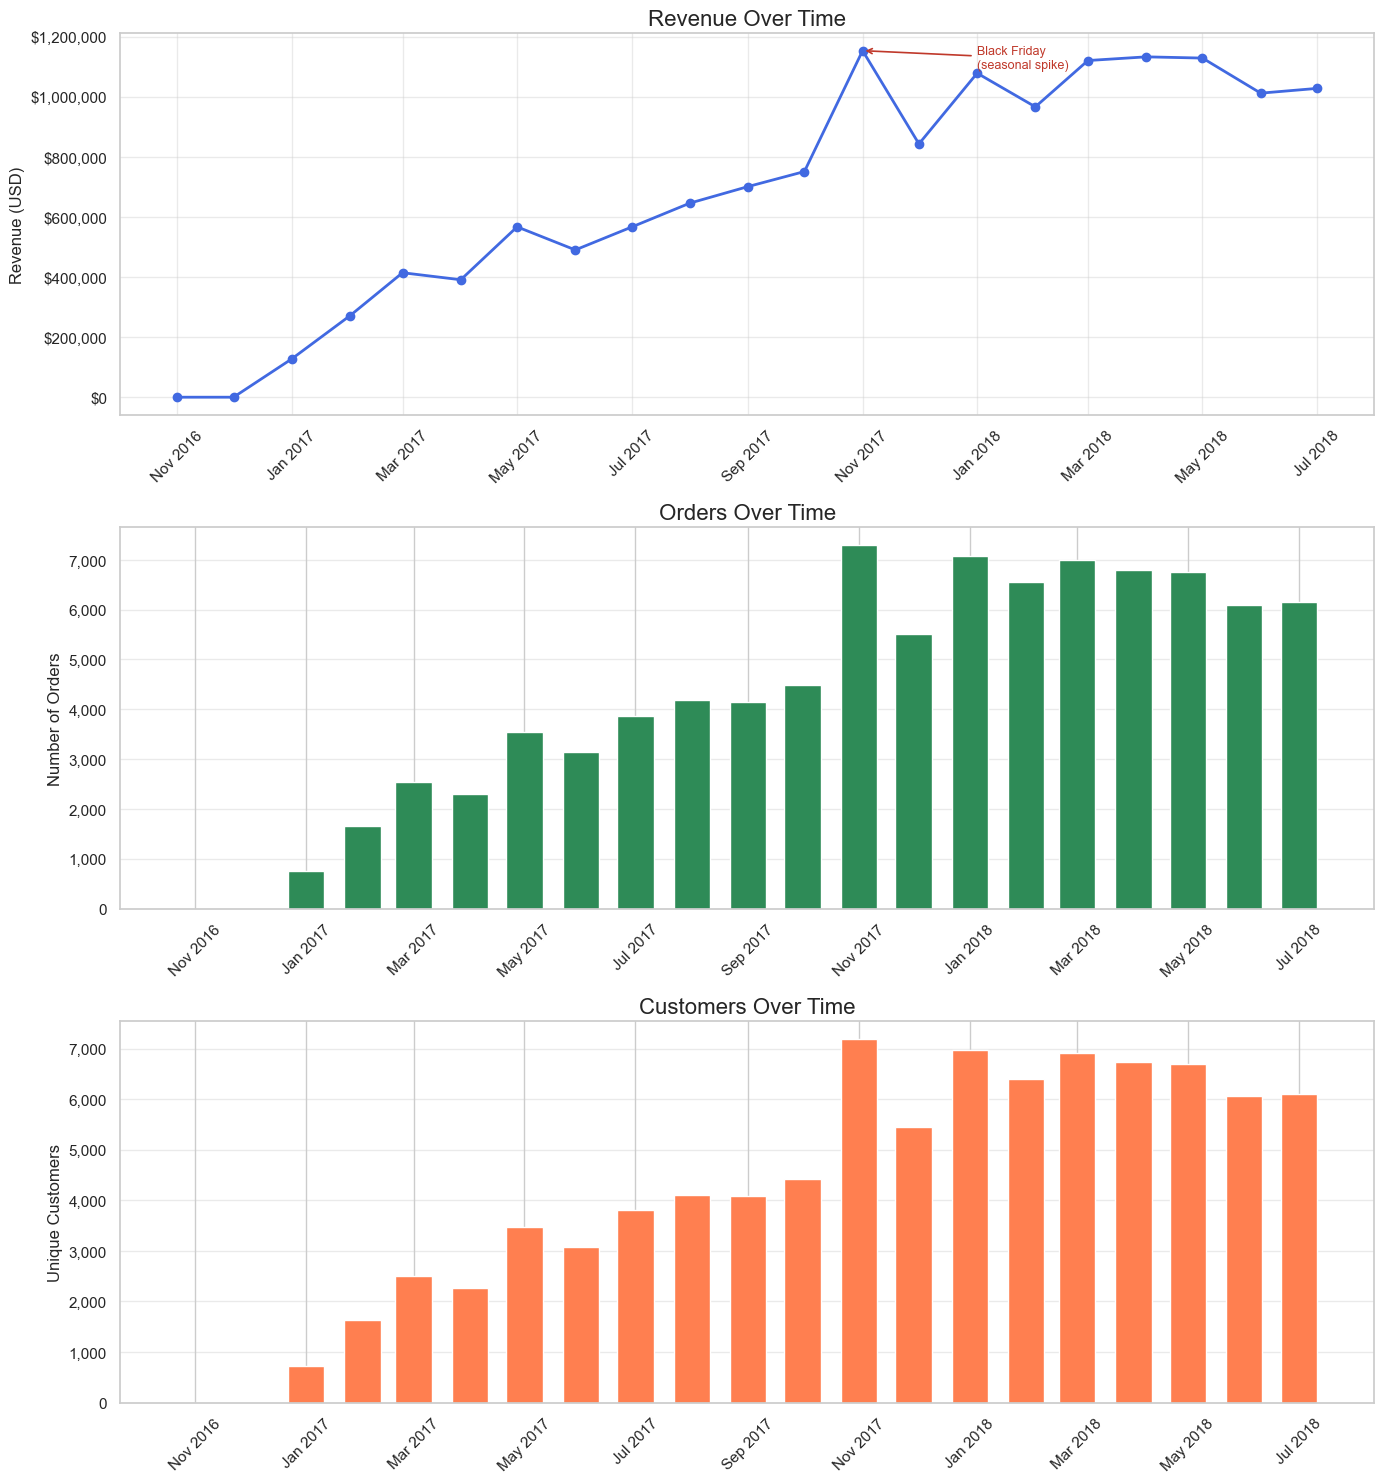


RFM Segment Stats:
        segment  customers  total_revenue  avg_revenue  revenue_share
           Lost      36227     5865102.23   161.898645      38.029611
VIP / Champions      15441     4733630.56   306.562435      30.693093
      Promising      39883     4328353.78   108.526284      28.065259
        At Risk        988      288813.96   292.321822       1.872684
          Loyal        818      206561.24   252.519853       1.339353


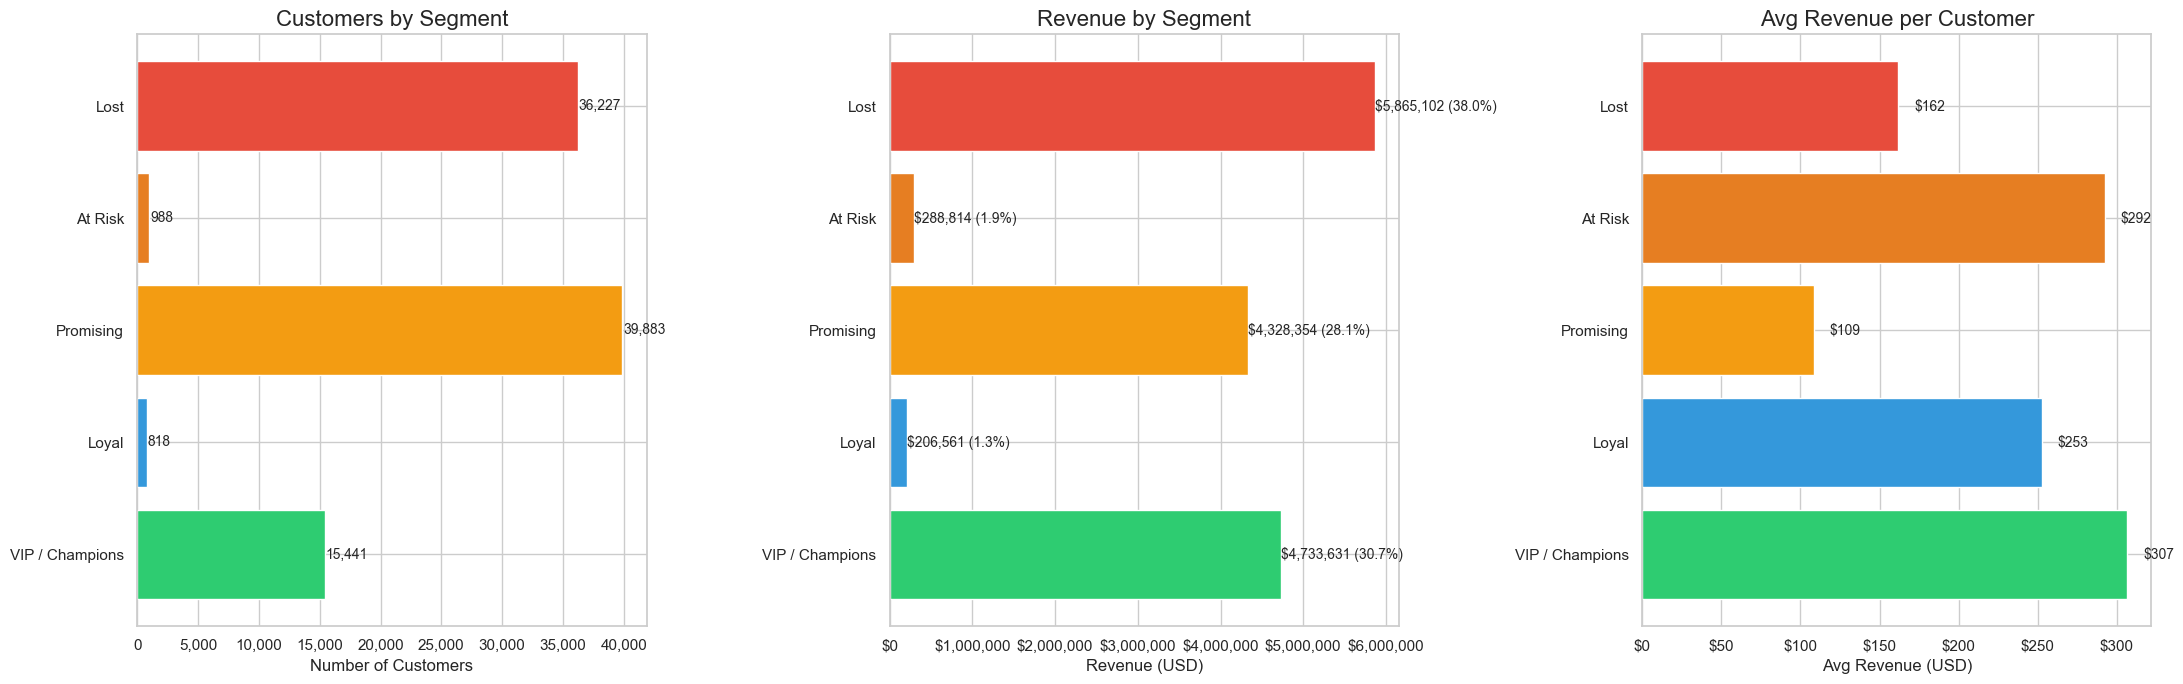


ABC Analysis:
                               category    revenue  revenue_share  cumulative_share abc
                          Health beauty 1411946.07       9.156809          9.156809   A
                          Watches gifts 1264333.12       8.199503         17.356312   A
                         Bed bath table 1225209.26       7.945776         25.302088   A
                         Sports leisure 1118256.91       7.252164         32.554252   A
                  Computers accessories 1032723.77       6.697461         39.251714   A
                        Furniture decor  880329.92       5.709151         44.960864   A
                             Housewares  758392.25       4.918356         49.879220   A
                             Cool stuff  691680.89       4.485716         54.364936   A
                                   Auto  669454.75       4.341575         58.706511   A
                           Garden tools  567145.68       3.678076         62.384587   A
                 

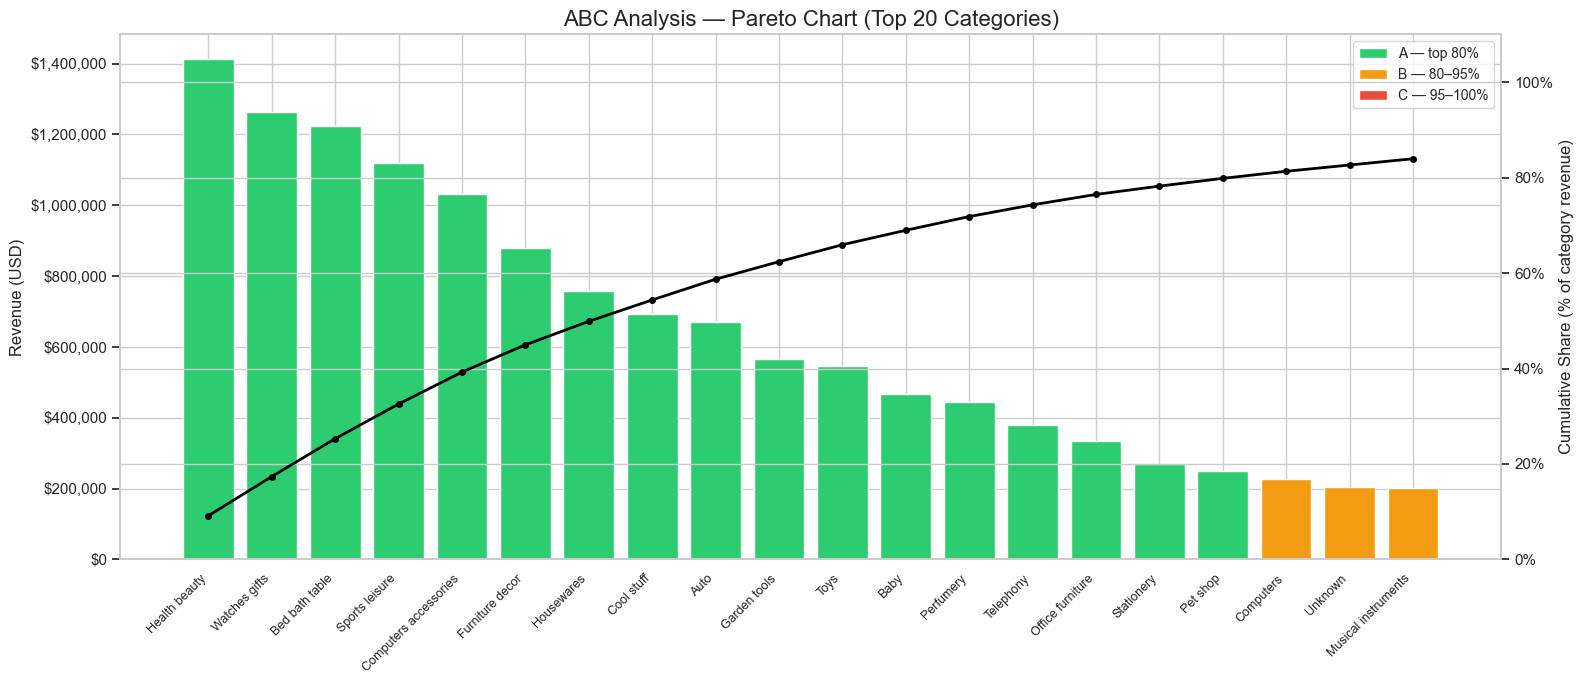

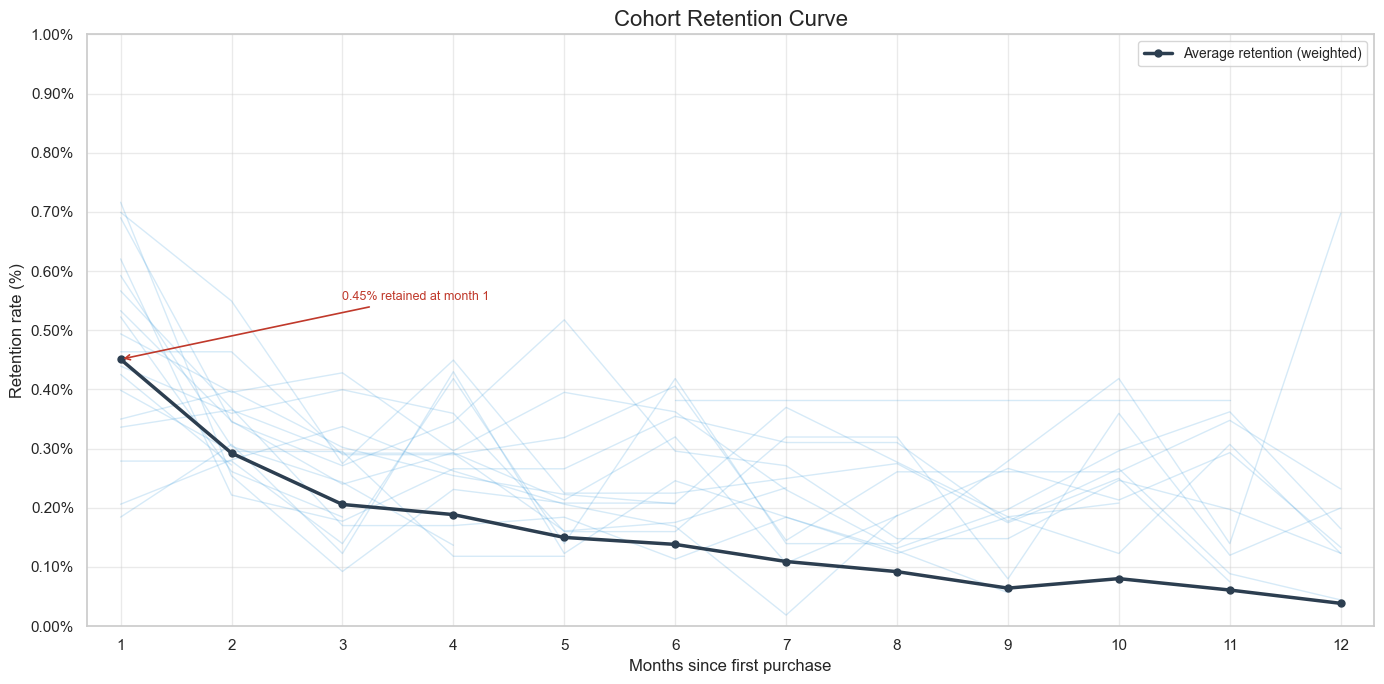


Average Retention by Period (weighted):
period
1     0.45%
2     0.29%
3     0.21%
4     0.19%
5     0.15%
6     0.14%
7     0.11%
8     0.09%
9     0.06%
10    0.08%
11    0.06%
12    0.04%
13    0.03%
14    0.02%
15    0.02%
16    0.01%
17    0.01%
19    0.00%
20    0.00%
dtype: object


In [ ]:
# 📌 Olist E-commerce Data Analysis
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch
sns.set_theme(style="whitegrid")

# ==========================================
# LOAD DATASETS
# ==========================================
customers      = pd.read_csv('olist_customers_dataset.csv')
products       = pd.read_csv('olist_products_dataset.csv')
order_items    = pd.read_csv('olist_order_items_dataset.csv')
payments       = pd.read_csv('olist_order_payments_dataset.csv')
orders         = pd.read_csv('olist_orders_dataset.csv')
category_trans = pd.read_csv('product_category_name_translation.csv')

# ==========================================
# PREPROCESSING & MERGING
# ==========================================
payments_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

df = pd.merge(orders, order_items, on='order_id', how='inner')
df = pd.merge(df, customers[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')
df = pd.merge(df, payments_agg, on='order_id', how='left')
df = pd.merge(df, products[['product_id', 'product_category_name']], on='product_id', how='left')
df = pd.merge(df, category_trans, on='product_category_name', how='left')

df.dropna(subset=['payment_value'], inplace=True)

df['product_category_name_english'] = (
    df['product_category_name_english']
    .str.replace('_', ' ')
    .str.capitalize()
    .fillna('Unknown')
)

for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    df[col] = pd.to_datetime(df[col])

df = df.drop(columns=['product_category_name'])
df = df[df['order_status'] == 'delivered']
df = df[df['payment_value'] > 0]

# ==========================================
# KPI
# ==========================================
orders_unique = df.drop_duplicates('order_id')
total_revenue = orders_unique['payment_value'].sum()
aov           = orders_unique['payment_value'].mean()

unique_customers_total = orders_unique['customer_unique_id'].nunique()
total_orders           = df['order_id'].nunique()

print(f"Total unique orders: {total_orders}")
print(f"Average Order Value: ${aov:.2f}")
print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Unique clients: {unique_customers_total:,}")

# ==========================================
# REVENUE / ORDERS / CUSTOMERS OVER TIME
# ==========================================
revenue_over_time = (
    orders_unique
    .groupby(pd.Grouper(key='order_purchase_timestamp', freq='MS'))['payment_value']
    .sum().iloc[1:-1]
)
orders_customers_over_time = (
    orders_unique
    .groupby(pd.Grouper(key='order_purchase_timestamp', freq='MS'))['customer_unique_id']
    .nunique().iloc[1:-1]
)
orders_over_time = (
    orders_unique
    .groupby(pd.Grouper(key='order_purchase_timestamp', freq='MS'))['order_id']
    .count().iloc[1:-1]
)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15))

ax1.plot(revenue_over_time.index, revenue_over_time.values,
         marker='o', linestyle='-', color='royalblue', linewidth=2)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.tick_params(axis='x', rotation=45)
ax1.set_title("Revenue Over Time", fontsize=16)
ax1.set_ylabel("Revenue (USD)", fontsize=12)
ax1.grid(True, alpha=0.4)

nov_2017 = pd.Timestamp('2017-11-01')
if nov_2017 in revenue_over_time.index:
    ax1.annotate(
        'Black Friday\n(seasonal spike)',
        xy=(nov_2017, revenue_over_time[nov_2017]),
        xytext=(nov_2017 + pd.DateOffset(months=2), revenue_over_time[nov_2017] * 0.95),
        fontsize=9, color='#c0392b',
        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2),
        ha='left'
    )

ax2.bar(orders_over_time.index, orders_over_time.values, color='seagreen', width=20)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.tick_params(axis='x', rotation=45)
ax2.set_title("Orders Over Time", fontsize=16)
ax2.set_ylabel("Number of Orders", fontsize=12)
ax2.grid(True, alpha=0.4, axis='y')

ax3.bar(orders_customers_over_time.index, orders_customers_over_time.values, color='coral', width=20)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.tick_params(axis='x', rotation=45)
ax3.set_title("Customers Over Time", fontsize=16)
ax3.set_ylabel("Unique Customers", fontsize=12)
ax3.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# ==========================================
# RFM
# ==========================================
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = orders_unique.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('payment_value', 'sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])

def f_score(x):
    if x == 1:   return 1
    elif x == 2: return 2
    elif x == 3: return 4
    else:        return 5

rfm['F'] = rfm['frequency'].apply(f_score)

rfm['M'] = pd.qcut(
    rfm['monetary'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]
)

def segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])
    if r >= 4 and (f >= 4 or m >= 4):  return 'VIP / Champions'
    elif r >= 3 and f >= 2:             return 'Loyal'
    elif r >= 3 and f == 1:             return 'Promising'
    elif r <= 2 and f >= 2:             return 'At Risk'
    else:                               return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)

segment_stats = rfm.groupby('segment').agg(
    customers=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_revenue=('monetary', 'mean')
).reset_index()

segment_stats['revenue_share'] = (
    segment_stats['total_revenue'] / segment_stats['total_revenue'].sum() * 100
)
segment_stats = segment_stats.sort_values('total_revenue', ascending=False)

print("\nRFM Segment Stats:")
print(segment_stats.to_string(index=False))

# ==========================================
# RFM VISUALIZATION
# ==========================================
segment_order  = ['VIP / Champions', 'Loyal', 'Promising', 'At Risk', 'Lost']
segment_colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
color_map      = dict(zip(segment_order, segment_colors))

plot_data = segment_stats.set_index('segment').reindex(segment_order).dropna()
colors    = [color_map[s] for s in plot_data.index]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

bars = ax1.barh(plot_data.index, plot_data['customers'], color=colors)
ax1.set_title("Customers by Segment", fontsize=16)
ax1.set_xlabel("Number of Customers", fontsize=12)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, plot_data['customers']):
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f}', va='center', fontsize=10)

bars2 = ax2.barh(plot_data.index, plot_data['total_revenue'], color=colors)
ax2.set_title("Revenue by Segment", fontsize=16)
ax2.set_xlabel("Revenue (USD)", fontsize=12)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, (val, share) in zip(bars2, zip(plot_data['total_revenue'], plot_data['revenue_share'])):
    ax2.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
             f'${val:,.0f} ({share:.1f}%)', va='center', fontsize=10)

bars3 = ax3.barh(plot_data.index, plot_data['avg_revenue'], color=colors)
ax3.set_title("Avg Revenue per Customer", fontsize=16)
ax3.set_xlabel("Avg Revenue (USD)", fontsize=12)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars3, plot_data['avg_revenue']):
    ax3.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
             f'${val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# ABC ANALYSIS
# ==========================================
df['item_revenue'] = df['price'] + df['freight_value']

category_revenue = (
    df.groupby('product_category_name_english')['item_revenue']
    .sum().sort_values(ascending=False).reset_index()
)
category_revenue.columns = ['category', 'revenue']

total_cat_revenue = category_revenue['revenue'].sum()
category_revenue['revenue_share']    = category_revenue['revenue'] / total_cat_revenue * 100
category_revenue['cumulative_share'] = category_revenue['revenue_share'].cumsum()

def abc_segment(cum_share):
    if cum_share <= 80:   return 'A'
    elif cum_share <= 95: return 'B'
    else:                 return 'C'

category_revenue['abc'] = category_revenue['cumulative_share'].apply(abc_segment)

print("\nABC Analysis:")
print(category_revenue[['category', 'revenue', 'revenue_share', 'cumulative_share', 'abc']].to_string(index=False))

top_n      = 20
plot_abc   = category_revenue.head(top_n).copy()
abc_colors = plot_abc['abc'].map({'A': '#2ecc71', 'B': '#f39c12', 'C': '#e74c3c'})

fig, ax1 = plt.subplots(figsize=(16, 7))
bars = ax1.bar(range(top_n), plot_abc['revenue'], color=abc_colors)
ax1.set_xticks(range(top_n))
ax1.set_xticklabels(plot_abc['category'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel("Revenue (USD)", fontsize=12)
ax1.set_title("ABC Analysis — Pareto Chart (Top 20 Categories)", fontsize=16)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(range(top_n), plot_abc['cumulative_share'], color='black',
         marker='o', linewidth=2, markersize=4)
ax2.set_ylabel("Cumulative Share (% of category revenue)", fontsize=12)
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

legend_elements = [
    Patch(facecolor='#2ecc71', label='A — top 80%'),
    Patch(facecolor='#f39c12', label='B — 80–95%'),
    Patch(facecolor='#e74c3c', label='C — 95–100%')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# COHORT RETENTION CURVE
# ==========================================
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

first_purchase = (
    df.groupby('customer_unique_id')['order_month']
    .min().reset_index().rename(columns={'order_month': 'cohort'})
)

df = df.merge(first_purchase, on='customer_unique_id', how='left')

cohort_data = (
    df.groupby(['cohort', 'order_month'])['customer_unique_id']
    .nunique().reset_index()
)

cohort_data['period'] = (
    cohort_data['order_month'] - cohort_data['cohort']
).apply(lambda x: x.n)

cohort_table = (
    cohort_data.groupby(['cohort', 'period'])['customer_unique_id']
    .sum().unstack('period')
)

cohort_sizes = cohort_table[0]
retention    = cohort_table.divide(cohort_sizes, axis=0)

weighted_retention = (
    cohort_table.iloc[:, 1:]
    .divide(cohort_sizes, axis=0)
    .multiply(cohort_sizes, axis=0)
    .sum()
    .divide(cohort_sizes.sum())
)

retention_plot = retention.loc[:, 0:12]

# --- Retention Curve (y-axis: 0–1%) ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

# Individual cohort lines (excluding period 0 = 100%)
for cohort_idx in retention_plot.index:
    values = retention_plot.loc[cohort_idx].drop(0, errors='ignore').dropna()
    if len(values) > 1:
        ax.plot(
            values.index, values.values * 100,
            color='#3498db', alpha=0.2, linewidth=1
        )

# Weighted average line
periods    = list(weighted_retention.index[:12])
avg_values = list(weighted_retention.values[:12] * 100)

ax.plot(
    periods, avg_values,
    color='#2c3e50', linewidth=2.5,
    marker='o', markersize=5, label='Average retention (weighted)'
)

# Annotate period-1
ax.annotate(
    f"{weighted_retention.iloc[0]*100:.2f}% retained at month 1",
    xy=(1, weighted_retention.iloc[0] * 100),
    xytext=(3, weighted_retention.iloc[0] * 100 + 0.1),
    fontsize=9, color='#c0392b',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2)
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
ax.set_xlim(0.7, 12.3)
ax.set_ylim(0, 1.0)
ax.set_yticks([i * 0.1 for i in range(11)])
ax.set_xticks(range(1, 13))
ax.set_xlabel("Months since first purchase", fontsize=12)
ax.set_ylabel("Retention rate (%)", fontsize=12)
ax.set_title("Cohort Retention Curve", fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("\nAverage Retention by Period (weighted):")
print(weighted_retention.apply(lambda x: f'{x:.2%}'))